In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Amplitude modulation example

Carrier wave  $$s_0(t)=A_c cos(2\pi f_c t)$$

Information signal $$m(t)=cos(2\pi f_m t)$$

Modulated wave $$s(t)=A_c \bigg(1+m \> cos(2 \pi f_m t)\bigg)cos(2\pi f_c t)$$

In [2]:
def modulateAM(info_signal, f_c, modulation_index, t = []):
    if len(t) == 0:
        t = np.linspace(0, 1, len(info_signal))
    return (1 + modulation_index * info_signal) * np.cos(2*np.pi*f_c*t)

In [3]:
A_c = 1
f_c = 400    
f_m = 20
modulation_index = 0.5  

In [4]:
t = np.linspace(0, 1, 100000)
carrier = A_c*np.cos(2*np.pi*f_c*t)
info = np.cos(2*np.pi*f_m*t)

am_signal = modulateAM(info, f_c, modulation_index)

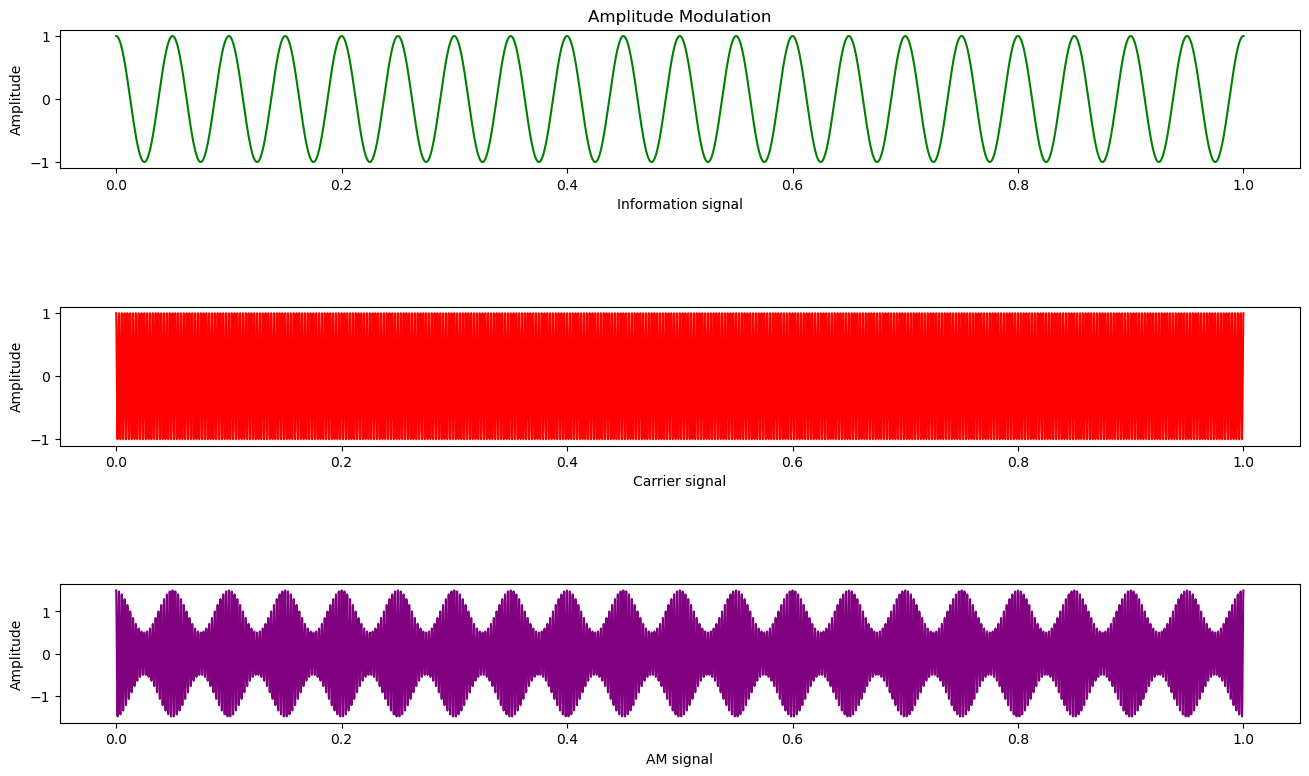

In [5]:
plt.subplot(3,1,1)
plt.title('Amplitude Modulation')
plt.plot(t, info,'g')
plt.ylabel('Amplitude')
plt.xlabel('Information signal')

plt.subplot(3,1,2)
plt.plot(t, carrier, 'r')
plt.ylabel('Amplitude')
plt.xlabel('Carrier signal')

plt.subplot(3,1,3)
plt.plot(t, am_signal, color="purple")
plt.ylabel('Amplitude')
plt.xlabel('AM signal')
plt.subplots_adjust(hspace=1)

plt.rc('font', size=15)
fig = plt.gcf()
fig.set_size_inches(16, 9)
#fig.savefig('Amplitude Modulation.png', dpi=100)

# Encoding sound with AM

In [6]:
import soundfile as sf
import scipy.signal as sg # Comment: Reads audio in floats, writes in non-empty file
import wavio # Comment: Reads audio in integers, writes in a new file

import matplotlib.ticker as ticker

In [7]:
def plotSignalTime(signal):
    plt.plot(signal)
    #plt.stem(signal)
    plt.ylabel('Amplitude')
    plt.xlabel('sample index')
    plt.rc('font', size=15)
    fig = plt.gcf()
    fig.set_size_inches(16, 5)

In [8]:
def plotAmplFreqResp(signal, Fs, use_log_scale = False, use_grid = True):   
    fft_signal = np.fft.fft(signal) # make FFT of info signal
    fft_signal = np.fft.fftshift(fft_signal) # shift FFT so that DC (zero frequency) is at center
    if use_log_scale:
        plt.plot(np.linspace(-Fs/2, Fs/2, len(fft_signal)), 20*np.log10(np.abs(fft_signal)))
        plt.ylabel('Amplitude, dB')
    else:
        plt.plot(np.linspace(-Fs/2, Fs/2, len(fft_signal)), np.abs(fft_signal) + 1e-12) # +epsilon to avoid log(0)
        plt.ylabel('Amplitude')
    plt.xlabel('Frequency, Hz')
    plt.rc('font', size=15)
    
    if use_grid:
        plt.grid(visible=1, which='both')
        plt.minorticks_on()
        plt.grid(which='major',
                linewidth = 2)
        plt.grid(which='minor', 
                linestyle = ':')
    
    fig = plt.gcf()
    fig.set_size_inches(16, 5) 

In [9]:
def plotPhaseFreqResp(fft_signal, Fs, use_grid = True):
    fft_signal = np.fft.fft(fft_signal) # make FFT of info signal
    fft_signal = np.fft.fftshift(fft_signal) # shift FFT so that DC (zero frequency) is at center
    
    plt.plot(np.linspace(-Fs/2, Fs/2, len(fft_signal)), np.angle(fft_signal))
    plt.ylabel('Phase')
    plt.xlabel('Frequency, Hz')
    plt.rc('font', size=15)
    
    if use_grid:
        plt.grid(visible=1, which='both')
        plt.minorticks_on()
        plt.grid(which='major',
                linewidth = 2)
        plt.grid(which='minor', 
                linestyle = ':')
    
    fig = plt.gcf()
    fig.set_size_inches(16, 5)

In [10]:
# Read audio data from file #

# Reads audio in floats
info_signal_orig, Fs = sf.read('sounds/citation1.wav') # read sound file and sampling frequency

# Reads audio in integers
#wav = wavio.read("sounds/result.wav")
#samples = wav.data
#Fs = wav.rate

print("Number of samples: ", len(info_signal_orig), ", sampling frequency:", Fs)

Number of samples:  14976 , sampling frequency: 16000


In [11]:
# Cut a portion of signal if needed #
do_cut = False

signal_start = 40000 #samples
signal_len = 80000 #samples

if do_cut:
    signal_duration = signal_len / Fs #seconds
    info_signal = info_signal_orig[signal_start:(signal_start+signal_len)] # get "info signal" as part of input signal 
else:
    signal_duration = len(info_signal_orig) / Fs #seconds
    info_signal = info_signal_orig # get "info signal" = input signal 

In [12]:
len(info_signal_orig)

14976

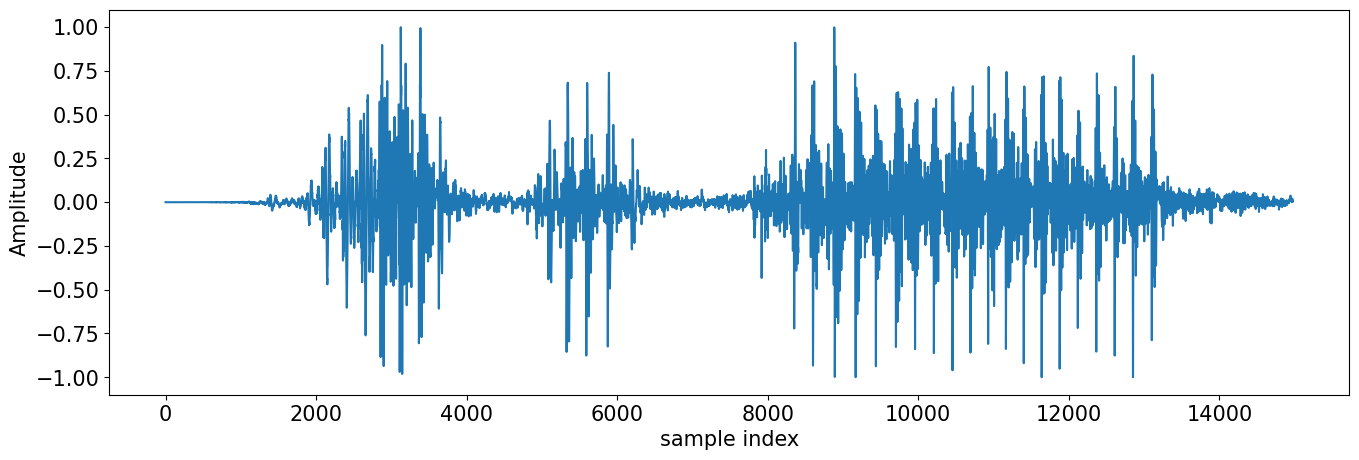

In [13]:
plotSignalTime(info_signal)

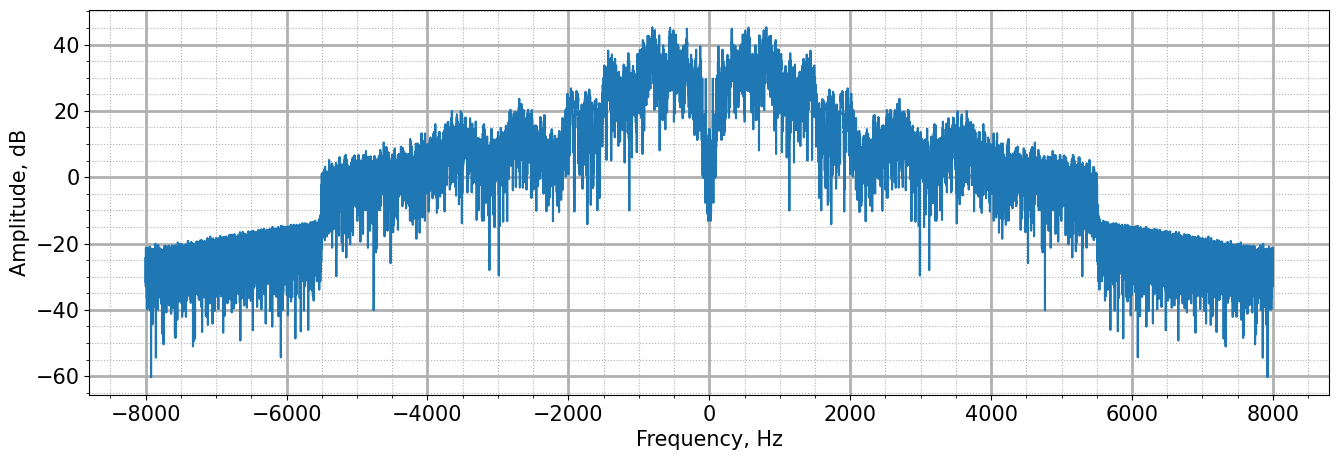

In [14]:
plotAmplFreqResp(info_signal, Fs, True)

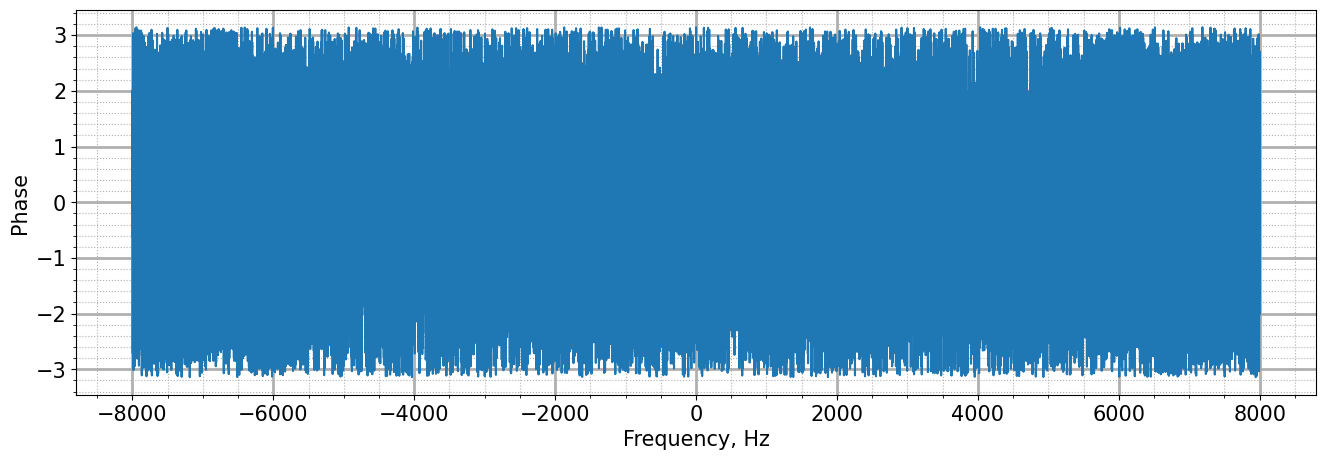

In [15]:
plotPhaseFreqResp(info_signal, Fs, True)

### HW1: What is the acceptable passband for this audio (bandwidth of this signal)? How do you determine it?
Answer: Основная часть реального амплитудного спектра сигнала в нашем случае расположена в диапазоне 0-5500 Гц (На 5500 Гц виден резкий спад, можно сказать, уже на уровене шумов). Но лучше не брать ровно границу - я бы сказал 6 кГц с запасом. Частоту дискретизации необходимо брать минимум вдвое большую, если мы хотим восстановить сигнал по дискретным отсчетам. Здесь частота дискретизации 16 кГц, и citation1.wav звучит неплохо, такой частоты дискретизации в исходном файле оказывается достаточно.

Загуглил - в старой телефонии использовались частоты до 3400 Гц. С таким фильтром звук и правда как из старого телефона) Думаю, это нужно было, чтобы экономить полосу частот, потому что основная разборчивая речь содержится как раз в этом диапазоне.

Но в моем случае я поставил фильтр на 3500-4000 Гц. Почему - объяснение в HW2.

In [16]:
# Build a Low Pass Filter before modulation # 

lpf = sg.iirdesign(3500, 4000, 0.001, 100, fs=Fs) # Select parameters in accordance with HW1 answers
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.iirdesign.html

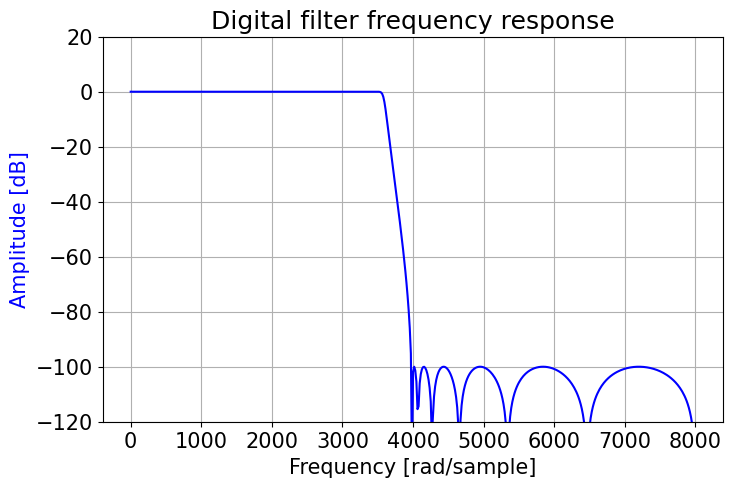

In [17]:
w, h = sg.freqz(*lpf, fs=Fs)

fig, ax1 = plt.subplots()
ax1.set_title('Digital filter frequency response')
ax1.plot(w, 20 * np.log10(abs(h)), 'b')
ax1.set_ylabel('Amplitude [dB]', color='b')
ax1.set_xlabel('Frequency [rad/sample]')
ax1.grid(True)
ax1.set_ylim([-120, 20])
nticks = 8
ax1.yaxis.set_major_locator(ticker.LinearLocator(nticks))
 
fig = plt.gcf()
fig.set_size_inches(8, 5) 

In [18]:
# Apply Low Pass Filter before modulation #

filtered_info_signal = sg.lfilter(*lpf, info_signal)

(-60.0, 50.0)

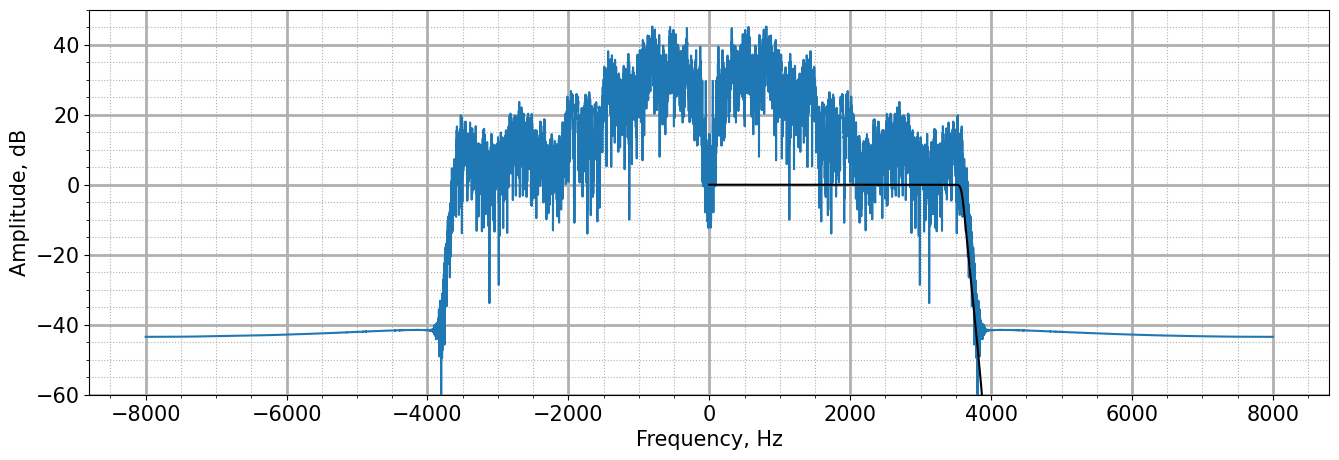

In [19]:
plotAmplFreqResp(filtered_info_signal, Fs, True)
plt.plot(w, 20 * np.log10(abs(h)), 'k')
plt.ylim((-60,50))

### HW2: Save this signal to an audio file.
Does it sound OK? Maybe too much high-frequency info is lost? Modify filtering parameters to find best parameters.

In [20]:
# TODO HW2 #

sf.write("sounds/my_filtered_citation1.wav", filtered_info_signal, Fs)

Ляпота. После прослушивания старого и нового явно чувствуется, что часть высокочастотных шумов убрана, а голос стал более басистым

### HW3: Do you always need to filter a modulating signal? Why (not)?
Answer:

Под modulating signal буду подразумевать низкочастотный информационный сигнал.

Думаю, проблемы могут возникнуть две:
1. В нашем случае мы рассматриваем частоту дискретизации 16 кГц и ею ограничены. 8 кГц - такой ширины может быть наш сигнал, поскольку при АМ модуляции он будет переноситься на несущую частоту вправо (и влево симметрично), из-за чего при бОльшей ширине сигнала он просто выйдет за пределы полосы Найквиста, либо наложится на спектр из отрицательных частот. Поэтому приходится ставить фильтр на 4 кГц, ограничивая полосу сигнала до 8 кГц.

2. (основная причина) Второй кейс может быть связан с тем, что для радиопередачи нам выделяют некоторую фиксированную узкую полосу в спектре. Мы не хотим вылезать за нее, поэтому перед передачей было бы неплохо отфильтровать передаваемый сигнал так, чтобы залесть в выделенную полосу. Иначе штрафуют(


In [21]:
len(am_signal)

100000

In [22]:
# Modulate the carrier frequency (in sound range) with a narrowband information (audio) signal 

f_c = Fs/4 # carrier frequency, Hz
modulation_index = 0.4
t = np.linspace(0, signal_duration, len(filtered_info_signal)) # array of samples timestampes
am_signal = modulateAM(filtered_info_signal, f_c, modulation_index, t)

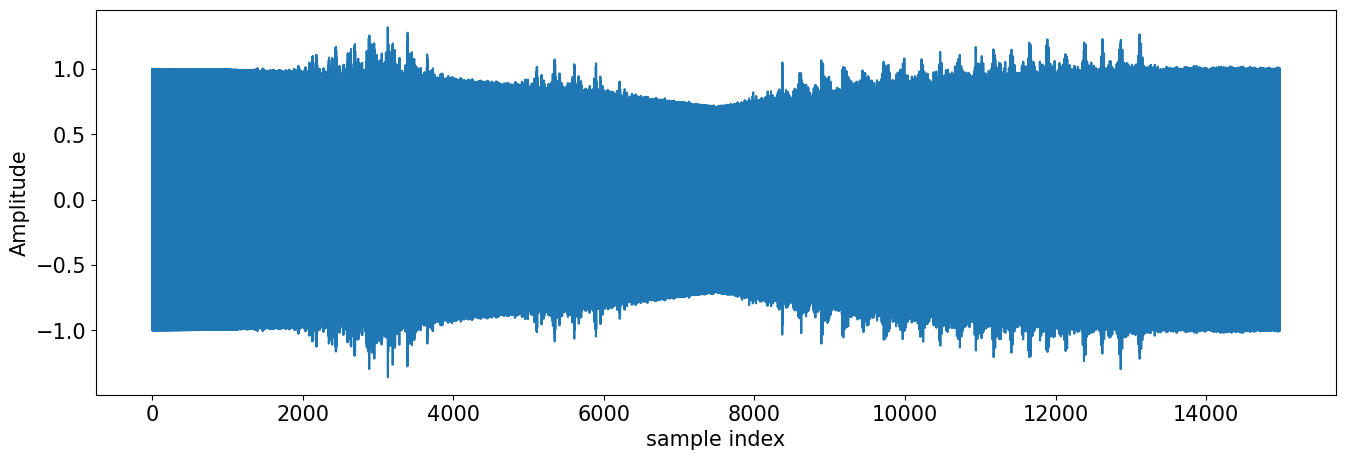

In [23]:
plotSignalTime(am_signal)

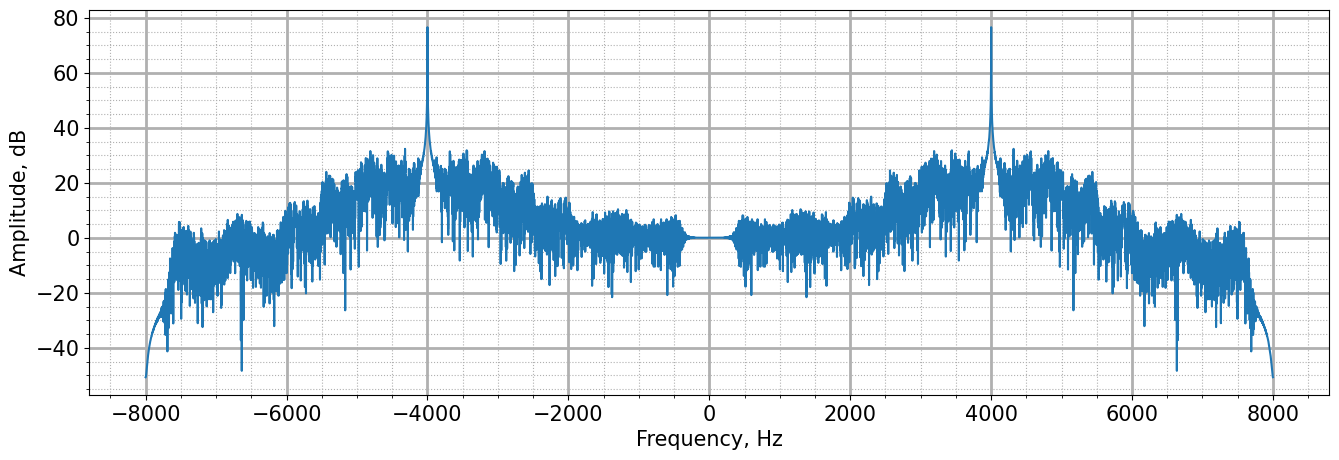

In [24]:
plotAmplFreqResp(am_signal, Fs, True)

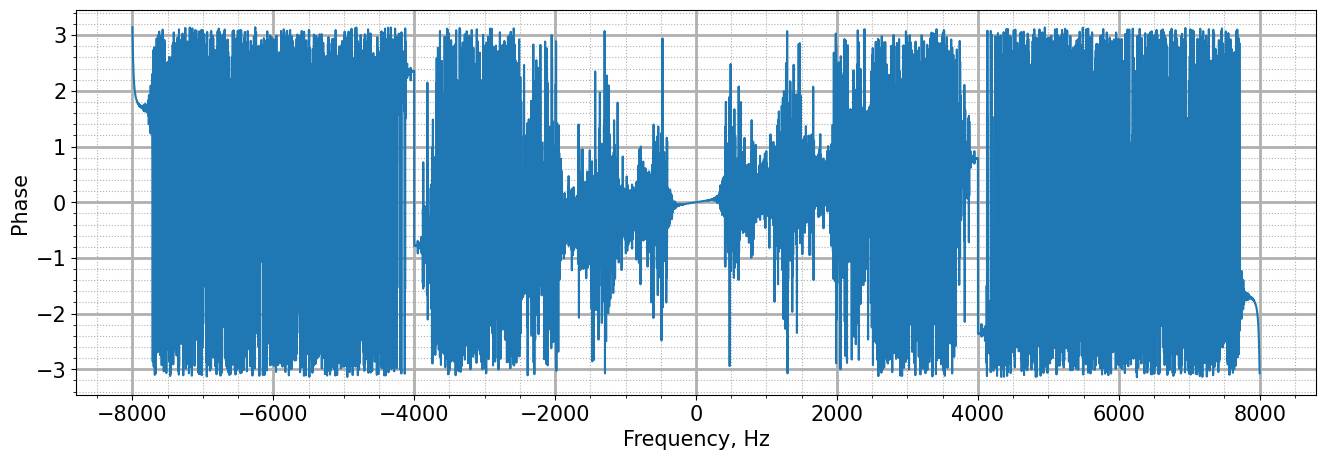

In [25]:
plotPhaseFreqResp(am_signal, Fs, True)

### HW4*: What AM variations can help reducing signal bandwidth?
Answer:

Нашел две вариации AM:
1. Подавляют несущую, которая имеет очень высокую мощность по сравнению с информационным сигналом, но при этом не несет полезной информации и лишь тратит ресурсы передатчика. DSB-SC https://en.wikipedia.org/wiki/Double-sideband_suppressed-carrier_transmission?ysclid=mm1d8uxtde292104035

2. АМ сигнал состоит из несущей и двух симметричных боковых гармоник. Зачем передавать симметричные гармоники, если можно передать только полезную часть? Эта идея лежит в основе SSB https://en.wikipedia.org/wiki/Single-sideband_modulation. Еще там вроде как к тому же и несущую подавляют

In [26]:
# # Comment: seems like writing with "signal" module requires non-empty file!
# #sf.read("sounds/am.wav", am_signal, Fs) # write signal to a sound file

# with sf.SoundFile('sounds/result1.wav', 'r+') as f:
#     f.seek(f.tell())
#     f.write(am_signal)

In [27]:
# # Write to WAV file
# Warning! Mind your speaker volume before playing audio!!

norm_am_signal = am_signal/max(am_signal) #normalize AM signal, otherwise wavio.write clips it. Warning: this reduces signal power!
# wavio.write("sounds/am.wav", norm_am_signal, Fs, sampwidth=2)

In [28]:
sf.write("sounds/am.wav", norm_am_signal, Fs)

# Demodulating AM signal

In [29]:
# Reading AM-modulated signal from file #

am_samples, Fs = sf.read('sounds/am.wav')

# Simulate channel noise #

noise = np.random.normal(0, #mean
                         0.01, #std
                         len(am_samples)) #length
am_signal_recorded = am_samples #+ noise

In [30]:
p_signal = np.var(am_samples)
p_noise = np.var(norm_am_signal - am_samples)
snr = 10 * np.log10(p_signal / p_noise)
print(f"SNR: {snr:.2f} dB")

p_signal = np.var(norm_am_signal)
p_noise = np.var(am_signal_recorded - norm_am_signal)
snr = 10 * np.log10(p_signal / p_noise)
print(f"SNR: {snr:.2f} dB")

SNR: 66.78 dB
SNR: 66.78 dB


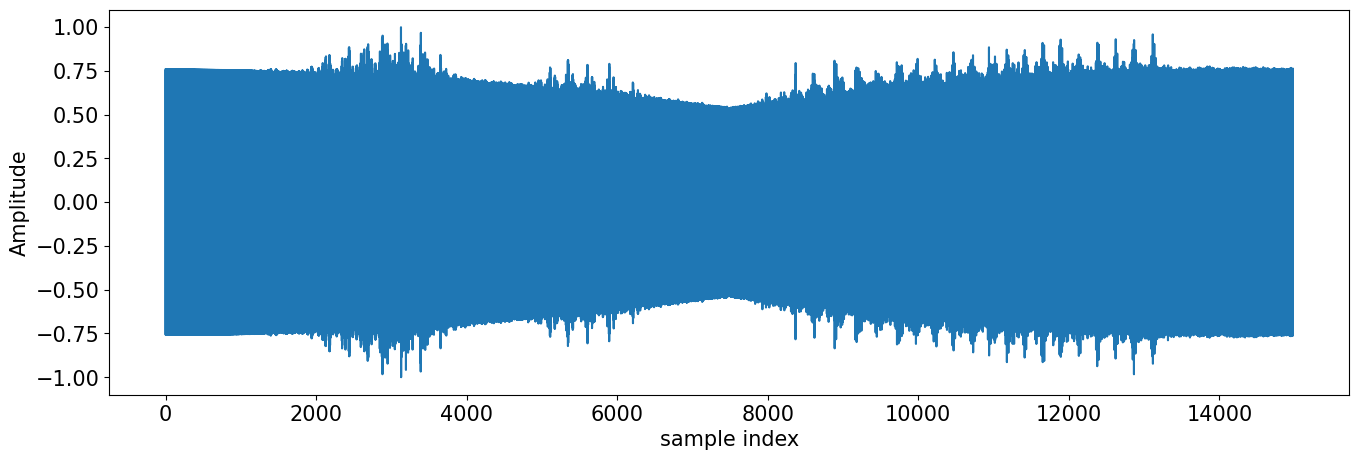

In [31]:
plotSignalTime(am_samples)

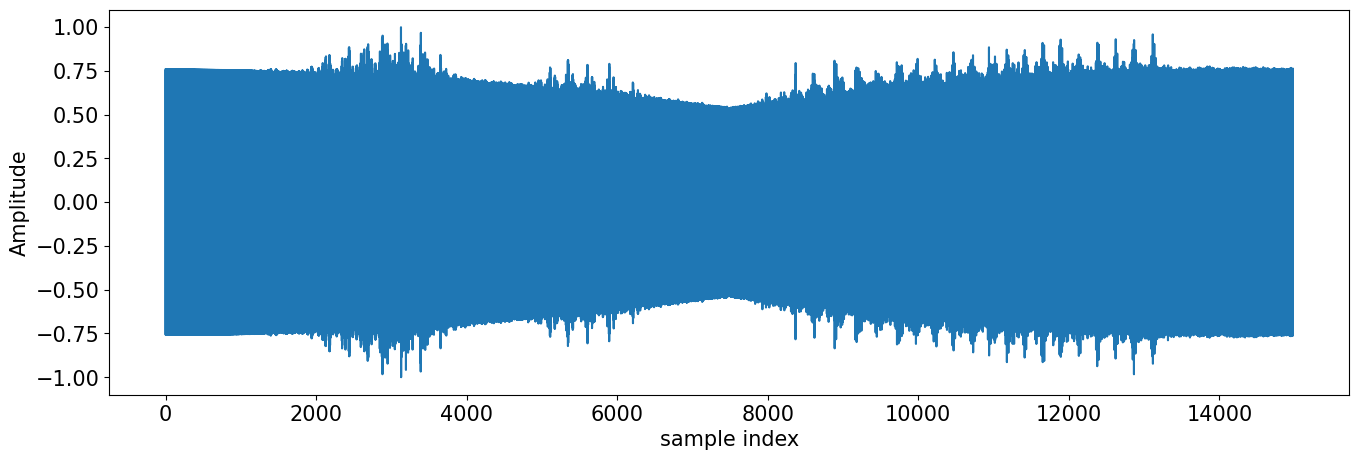

In [32]:
plotSignalTime(am_signal_recorded)

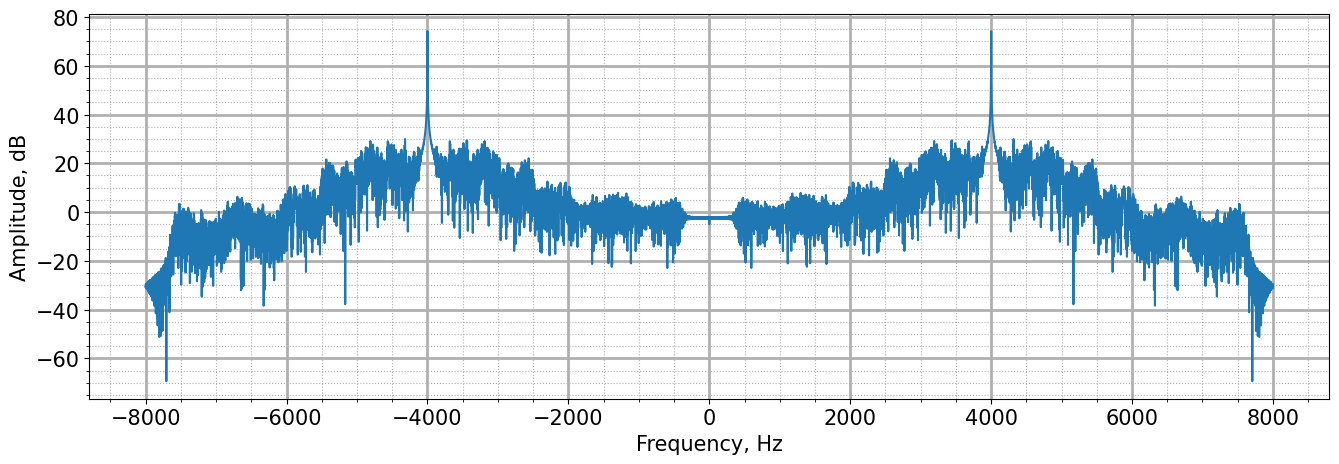

In [33]:
plotAmplFreqResp(am_signal_recorded, Fs, True, True)

In [34]:
# Build a Low Pass Filter to demodulate # 

lpf = sg.iirdesign(3500, 4000, 0.001, 100, fs=Fs) # Choose correct parameters!

In [35]:
# Demodulate AM - multiply signal by same frequency and filter it #

restored_signal = am_signal_recorded * np.cos(2*np.pi*f_c*t)

filtered_signal = sg.lfilter(*lpf, restored_signal)*2/modulation_index

# Remove DC component, (un)comment optionally
filtered_signal = filtered_signal - np.mean(filtered_signal) 

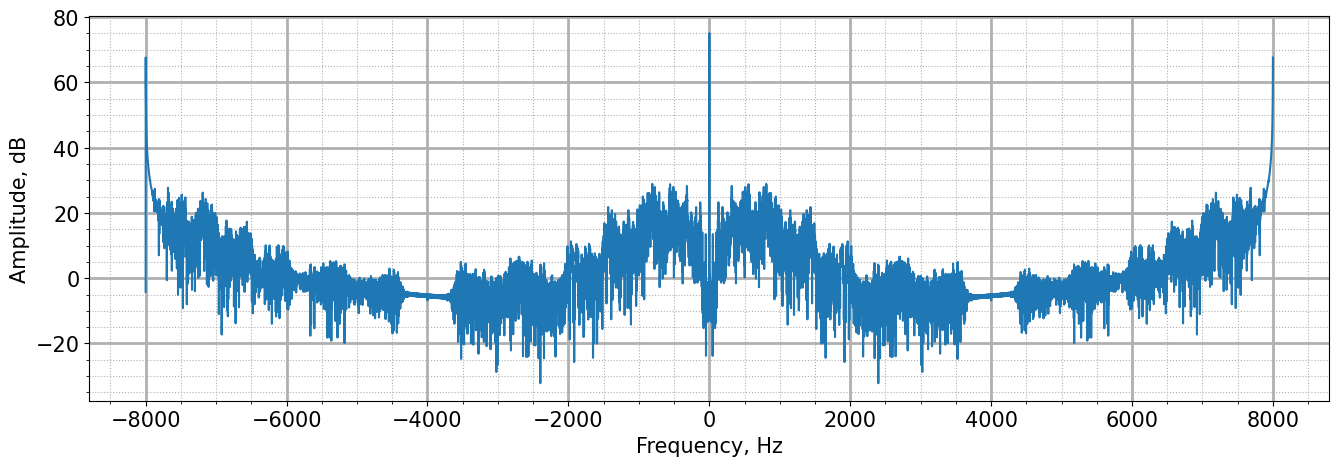

In [36]:
plotAmplFreqResp(restored_signal, Fs, True)

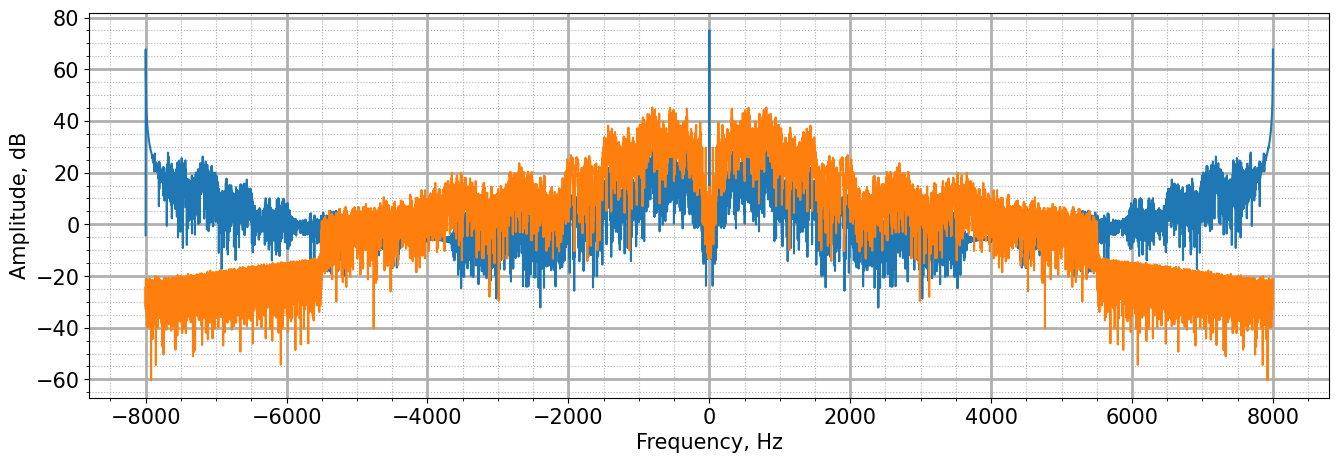

In [37]:
plotAmplFreqResp(restored_signal, Fs, True)
plotAmplFreqResp(info_signal, Fs, True)

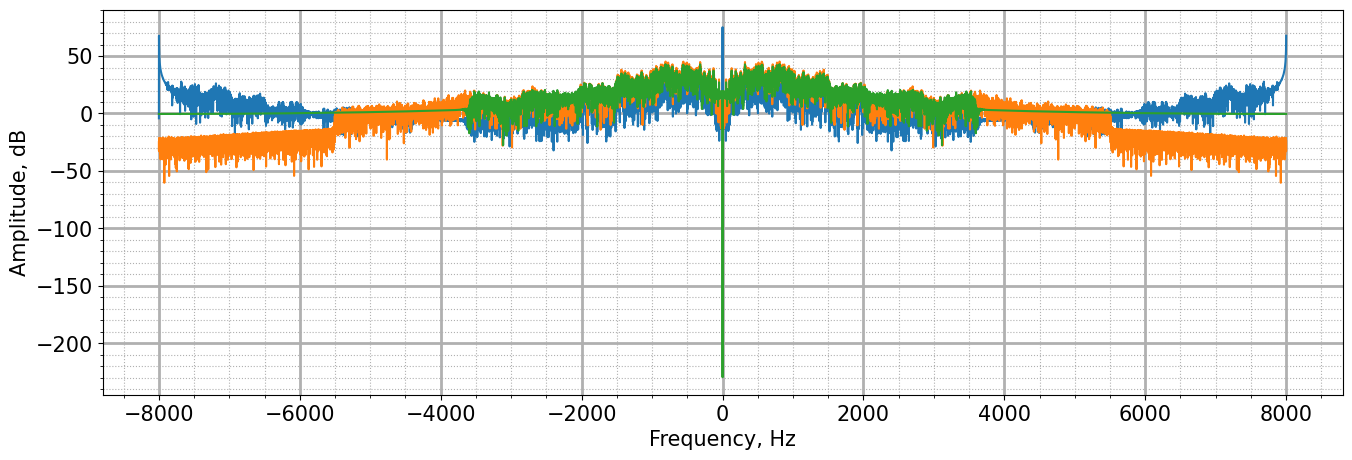

In [38]:
plotAmplFreqResp(restored_signal, Fs, True)
plotAmplFreqResp(info_signal, Fs, True)
plotAmplFreqResp(filtered_signal, Fs, True)

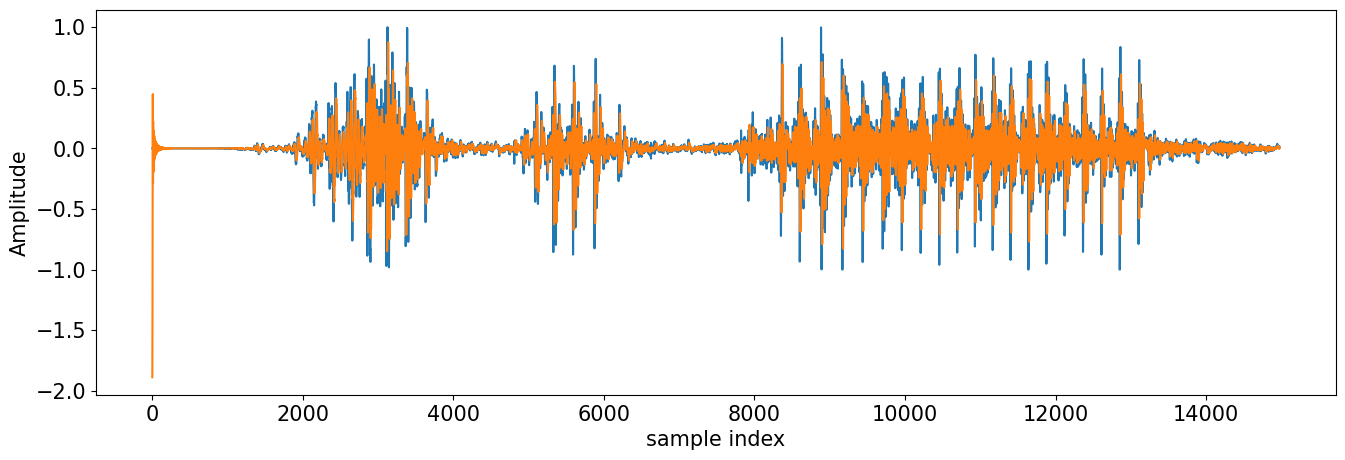

In [39]:
plotSignalTime(info_signal)
plotSignalTime(filtered_signal)

In [40]:
# Write resulting audio to audio file #

norm_filtered_signal = filtered_signal/max(filtered_signal) #normalize signal, otherwise wavio.write clips it
wavio.write("sounds/result1.wav", norm_filtered_signal, Fs, sampwidth=2)

c:\Users\Skifv\miniconda3\Lib\site-packages\wavio.py:259: ClippedDataWarning: Some data values have been clipped.  With scale=1.0, the interval of input values that will not be clipped is [-1.0000305180437934, 1.0]
  _warnings.warn(ClippedDataWarning(msg))


### HW6: Compare the quality of the inital audio and the demodulated recording.
Write a short description of your observations.

Парочка теоретических заметок:
Вернемся к тому, что наша частота дискретизации ограничена 16 кГц. Из-за этого при демодуляции, когда бы домножаем на косинус, левый лепесток перемещается как на нулевую, так и на удвоенную частоту. Но на удвоенной частоте (8кГц), его левый хвост выходит влево за полосу Найквиста и попадает в -1 зону Найквиста. Сигнал дискретный, поэтому он копируется в 0 зону Найквиста, наблюдается эффект алиасинга

Ну, либо это можно интерпретировать как отражение правого лепестка от границы зоны Найквиста
    
Частоты для фильтра я подобрал порядка 3500, потому что боковые лепестки сильно спадают уже при отступе в 2 кГц, при более малой частоте у фильтра звук был хуже.

В итоге, проварьировав при этом шум, обнаружил, что при его отсутствии эффект алиасинга практически не заметен. Помехи создаются только шумом

Ну еще отмечу, что высоких частот убавилось, голос стал более басистым

### HW7: Inspect how signal responds to strong noise.
Write a short description of your observations.

std == 0.001 - почти не был заметен шум

std == 0.01 - чувствуются помехи

std == 0.1 - разобрать речь можно, но все грустно. Примерно так меня слышат тиммейты в играх :)))))

std == 1 - на удивление все еще можно разобрать

std == 2 - разобрать речь невозможно

# Demodulate secret AM signal
### HW8: Demodulate am_secret1 (+1). 
Select the apropriate parameters for correct demodulation. 
Use any python tools needed.
Write a short description of what you saw and how you approached the task.

Не буду менять названия переменных, лень ))

In [41]:
# Reading AM-modulated signal from file #

am_samples, Fs = sf.read('sounds/am_secret1.wav')

signal_duration = len(am_samples) / Fs

t = np.linspace(0, signal_duration, len(am_samples))

# Simulate channel noise #

noise = np.random.normal(0, #mean
                         0.01, #std
                         len(am_samples)) #length
am_signal_recorded = am_samples  #+ noise

print(Fs)
print(len(am_samples))

44100
80000


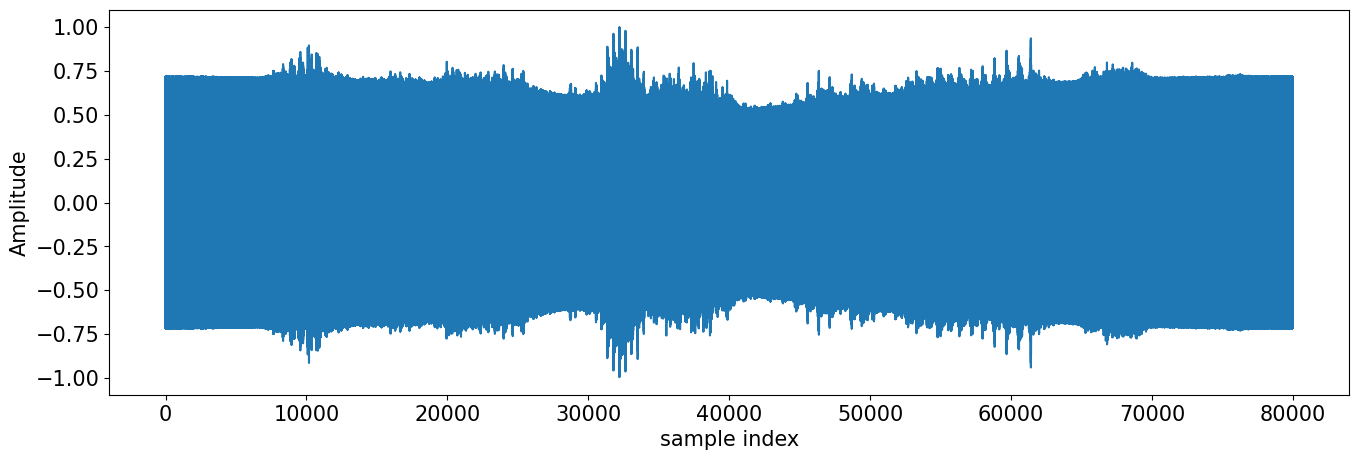

In [42]:
plotSignalTime(am_samples)

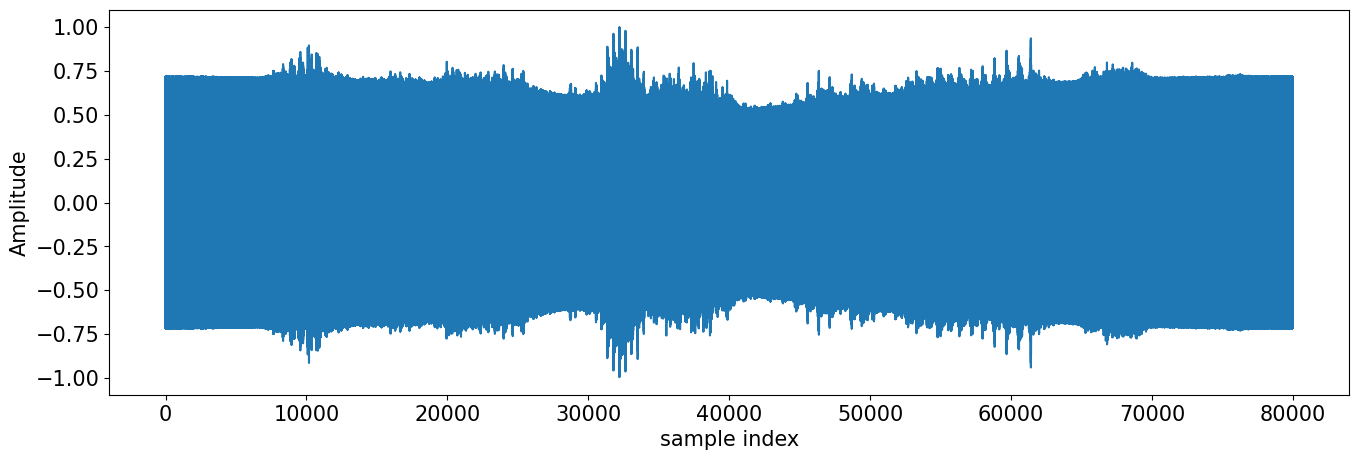

In [43]:
plotSignalTime(am_signal_recorded)

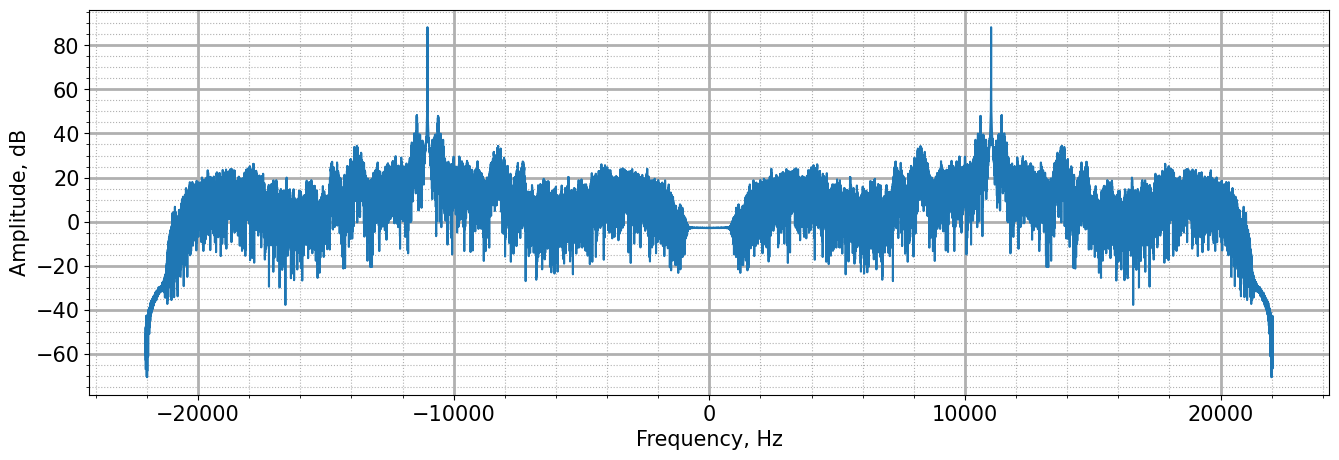

In [44]:
plotAmplFreqResp(am_signal_recorded, Fs, True, True)

По идее можно отфильтровать на Fs/4, так можно избежать алиасинга от левой гармоники

In [45]:
# Build a Low Pass Filter to demodulate # 

lpf = sg.iirdesign(Fs/4, Fs/4 + 500, 0.001, 100, fs=Fs) # Choose correct parameters!

Надо понять частоту несущей. В спектре находим пик (на какой частоте), используем argmax

In [46]:
fft_signal = np.fft.fft(am_signal_recorded) # make FFT of info signal
fft_signal = np.fft.fftshift(fft_signal) # shift FFT so that DC (zero frequency) is at center
# [-Fs/2, Fs/2]

freqs = np.linspace(-Fs/2, Fs/2, len(fft_signal))

f_c = freqs[np.argmax(fft_signal)]

print(f_c)

11025.41344266804


Надо понять высоты центрального пика и боковых лепестков. Буду искать через scipy

In [47]:
from scipy.signal import find_peaks

magnitudes_db = 20 * np.log10(np.abs(fft_signal))

# Ищем пики на положительной стороне (частоты > 0)

pos_mask = freqs > 0
freqs_pos = freqs[pos_mask]
mags_pos = magnitudes_db[pos_mask]

# Ищем пики
peaks, properties = find_peaks(mags_pos)

# Сортируем найденные пики по высоте (от больших к малым)
sorted_peaks = peaks[np.argsort(mags_pos[peaks])][::-1]

# Самый большой пик — это несущая (ее уже нашли, но так можем себя проверить)
carrier_idx = sorted_peaks[0]
carrier_freq = freqs_pos[carrier_idx]
carrier_level = mags_pos[carrier_idx]

# Второй и третий по величине — это боковые полосы
sideband1_idx = sorted_peaks[1]
sideband_freq = freqs_pos[sideband1_idx]
sideband_level = mags_pos[sideband1_idx]

diff = carrier_level - sideband_level

print(f"Несущая: {carrier_freq:.2f} Hz, уровень: {carrier_level:.2f} dB")
print(f"Боковая полоса: {sideband_freq:.2f} Hz, уровень: {sideband_level:.2f} dB")
print(f"Разница: {diff:.2f} dB")

Несущая: 11025.41 Hz, уровень: 88.24 dB
Боковая полоса: 11437.75 Hz, уровень: 48.36 dB
Разница: 39.87 dB


ΔdB=20log 
10
​
 (m/2)

 Находим m

In [48]:
modulation_index = 10**(-diff / 20) * 2

print(modulation_index)

0.020290029180426983


0.02 - адекватная величина m, особенно если взглянуть на график АЧХ НЕ в дБ

Либо мой метод расчета неверный... Но глобально, это домножение ни на что не влияет - мы потом все равно нормализуем значение на 1

In [49]:
# Demodulate AM - multiply signal by same frequency and filter it #

restored_signal = am_signal_recorded * np.cos(2*np.pi*f_c*t)

filtered_signal = sg.lfilter(*lpf, restored_signal)*2/modulation_index

# Remove DC component, (un)comment optionally
filtered_signal = filtered_signal - np.mean(filtered_signal) 

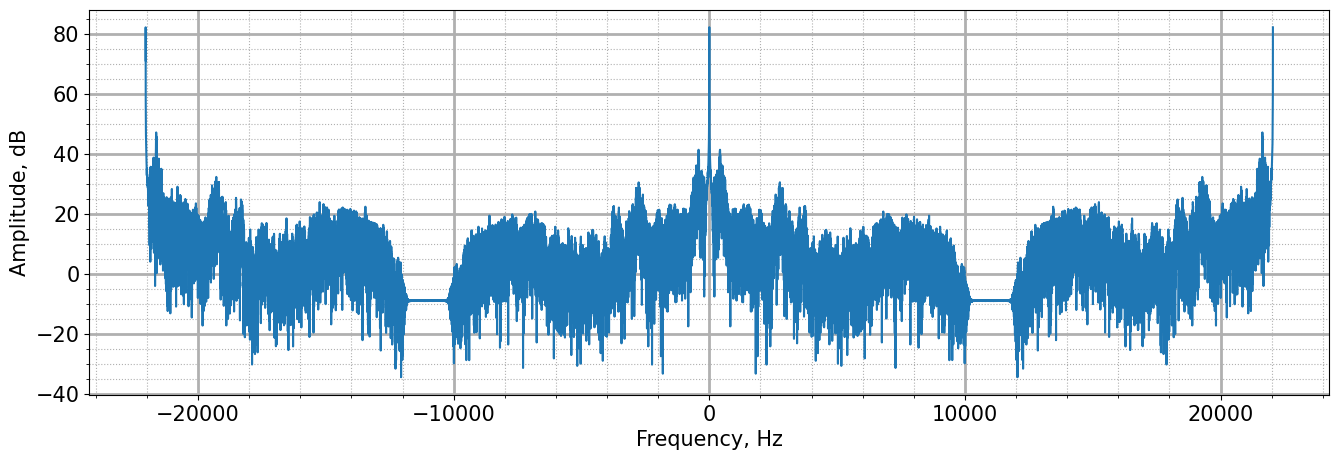

In [50]:
plotAmplFreqResp(restored_signal, Fs, True)

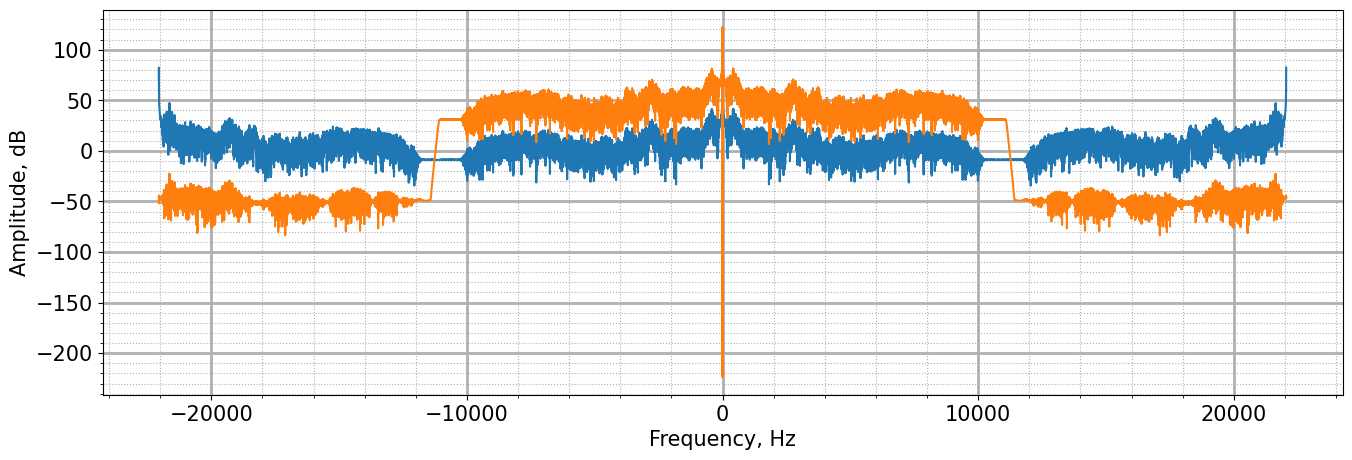

In [51]:
plotAmplFreqResp(restored_signal, Fs, True)
plotAmplFreqResp(filtered_signal, Fs, True)

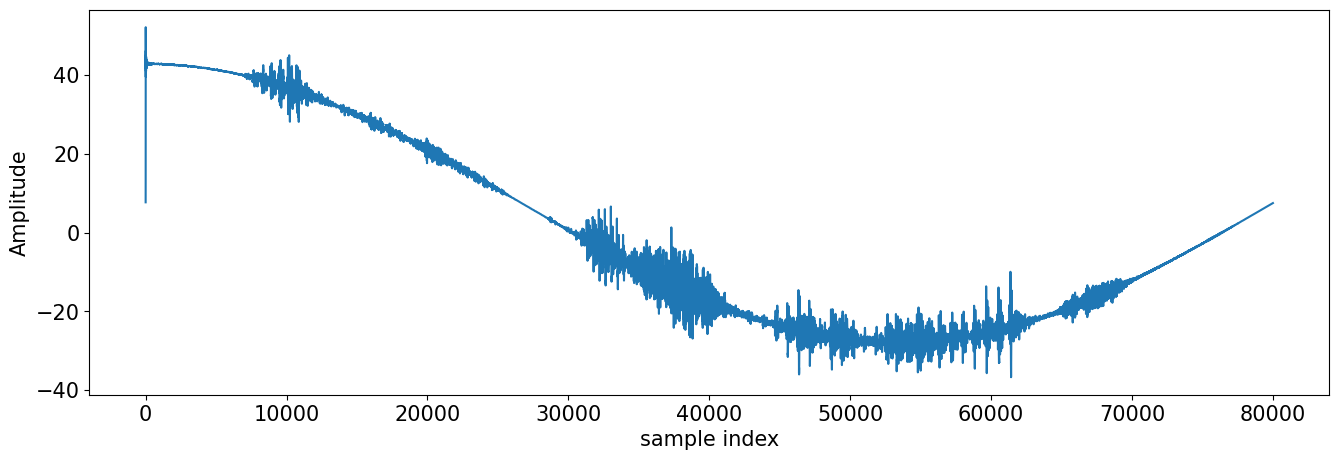

In [52]:

plotSignalTime(filtered_signal)

In [53]:
# Write resulting audio to audio file #

norm_filtered_signal = filtered_signal/max(filtered_signal) #normalize signal, otherwise wavio.write clips it
wavio.write("sounds/result_secret_1.wav", norm_filtered_signal, Fs, sampwidth=2)

В целом слышно неплохо. Цитата из Шерлока Холмса: "Нет ничего проще, дорогой Ватсон".

Спасибо за пасхалку!

Из того что я для себя вынес - можно фильтровать в полосе Fs/4, этого полностью достаточно, чтобы избежать алиасинга. Окончательно убедился только тогда, когда полностью убрал шум. С шумом, конечно, не все идеально. Выводы для себя сделал

### HW9*: Demodulate am_secret2 (+1). 
Select the apropriate parameters for correct demodulation. 
Use any python tools needed.
Write a short description of what you saw and how you approached the task.

Просто скопирую HW8

Не буду менять названия переменных, лень ))

In [54]:
# Reading AM-modulated signal from file #

am_samples, Fs = sf.read('sounds/am_secret2.wav')

signal_duration = len(am_samples) / Fs

t = np.linspace(0, signal_duration, len(am_samples))

# Simulate channel noise #

noise = np.random.normal(0, #mean
                         0.01, #std
                         len(am_samples)) #length
am_signal_recorded = am_samples  #+ noise

print(Fs)
print(len(am_samples))

44100
176400


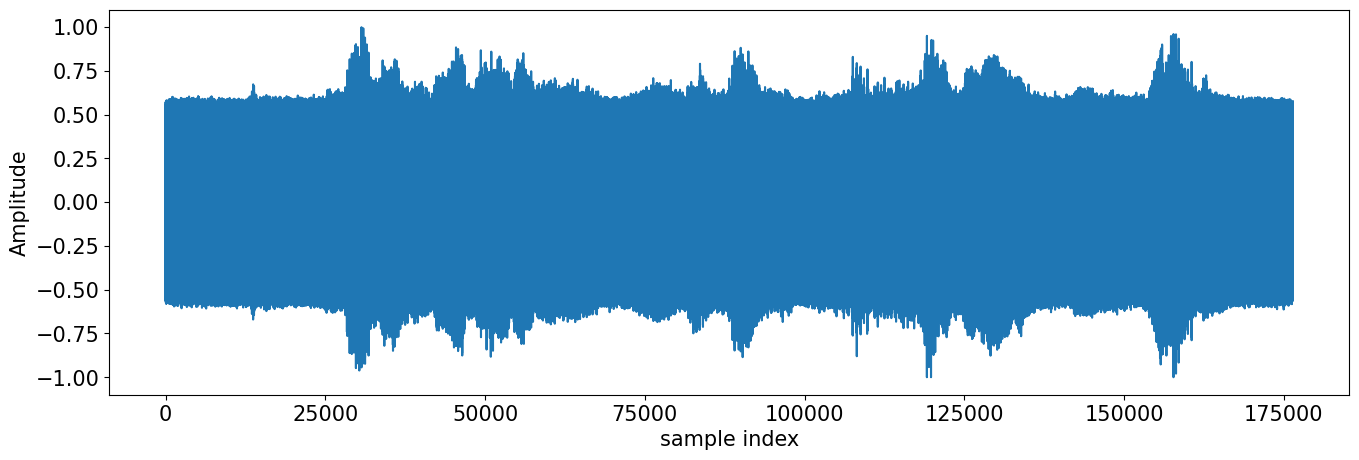

In [55]:
plotSignalTime(am_samples)

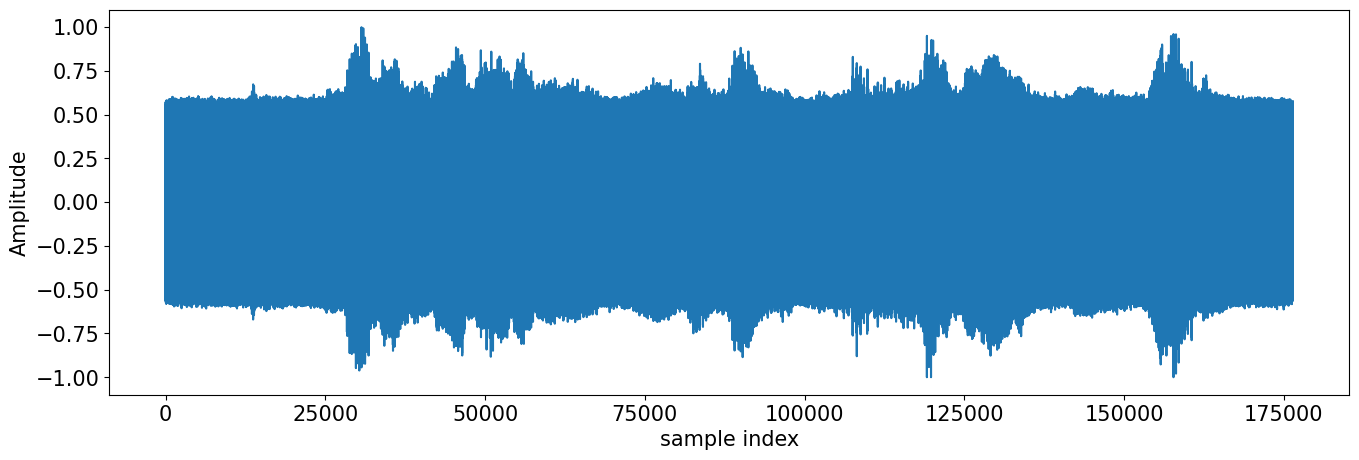

In [56]:
plotSignalTime(am_signal_recorded)

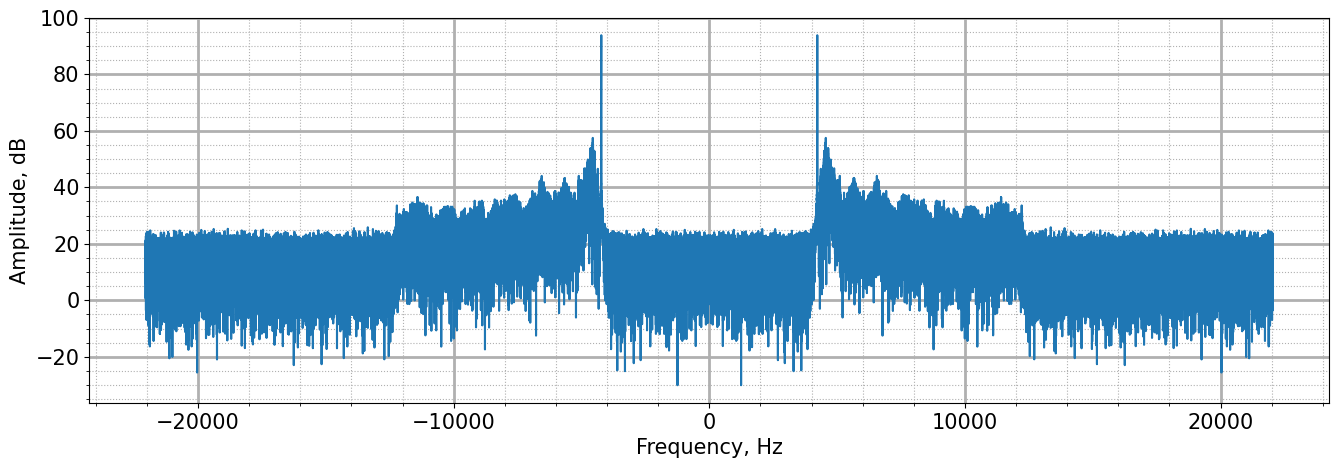

In [57]:
plotAmplFreqResp(am_signal_recorded, Fs, True, True)

Уже фильтровать надо не на Fs/4!! Так мы не отсечем удвоенную частоту после демодуляции

Кроме того, специфика спектра такова, что можно отфильтровать по частоте, очень близкой к 2f_c, потому что посередине очень большой кусок вырезан, и мы не захватим "лишнего"

Ранее просто так совпало, что f_c == Fs/4, и я ввел себя в заблуждение, что надо фильтровать на Fs/4

Надо понять частоту несущей. В спектре находим пик (на какой частоте), используем argmax

In [58]:
fft_signal = np.fft.fft(am_signal_recorded) # make FFT of info signal
fft_signal = np.fft.fftshift(fft_signal) # shift FFT so that DC (zero frequency) is at center
# [-Fs/2, Fs/2]

freqs = np.linspace(-Fs/2, Fs/2, len(fft_signal))

f_c = np.abs(freqs[np.argmax(fft_signal)])

print(f_c)

4224.898950674324


In [59]:
# Build a Low Pass Filter to demodulate # 

lpf = sg.iirdesign(0.9*2*f_c, 0.9*2*f_c + 500, 0.001, 100, fs=Fs) # Choose correct parameters!

Надо понять высоты центрального пика и боковых лепестков. Буду искать через scipy

In [60]:
from scipy.signal import find_peaks

magnitudes_db = 20 * np.log10(np.abs(fft_signal))

# Ищем пики на положительной стороне (частоты > 0)

pos_mask = freqs > 0
freqs_pos = freqs[pos_mask]
mags_pos = magnitudes_db[pos_mask]

# Ищем пики
peaks, properties = find_peaks(mags_pos)

# Сортируем найденные пики по высоте (от больших к малым)
sorted_peaks = peaks[np.argsort(mags_pos[peaks])][::-1]

# Самый большой пик — это несущая (ее уже нашли, но так можем себя проверить)
carrier_idx = sorted_peaks[0]
carrier_freq = freqs_pos[carrier_idx]
carrier_level = mags_pos[carrier_idx]

# Второй и третий по величине — это боковые полосы
sideband1_idx = sorted_peaks[1]
sideband_freq = freqs_pos[sideband1_idx]
sideband_level = mags_pos[sideband1_idx]

diff = carrier_level - sideband_level

print(f"Несущая: {carrier_freq:.2f} Hz, уровень: {carrier_level:.2f} dB")
print(f"Боковая полоса: {sideband_freq:.2f} Hz, уровень: {sideband_level:.2f} dB")
print(f"Разница: {diff:.2f} dB")

Несущая: 4225.15 Hz, уровень: 93.87 dB
Боковая полоса: 4557.65 Hz, уровень: 57.52 dB
Разница: 36.35 dB


ΔdB=20log 
10
​
 (m/2)

 Находим m

In [61]:
modulation_index = 10**(-diff / 20) * 2

print(modulation_index)

0.03043923881982222


0.03 - адекватная величина m, особенно если взглянуть на график АЧХ НЕ в дБ

Либо мой метод расчета неверный... Но глобально, это домножение ни на что не влияет - мы потом все равно нормализуем значение на 1

In [62]:
# Demodulate AM - multiply signal by same frequency and filter it #

restored_signal = am_signal_recorded * np.cos(2*np.pi*f_c*t)

filtered_signal = sg.lfilter(*lpf, restored_signal)*2/modulation_index

# Remove DC component, (un)comment optionally
filtered_signal = filtered_signal - np.mean(filtered_signal) 

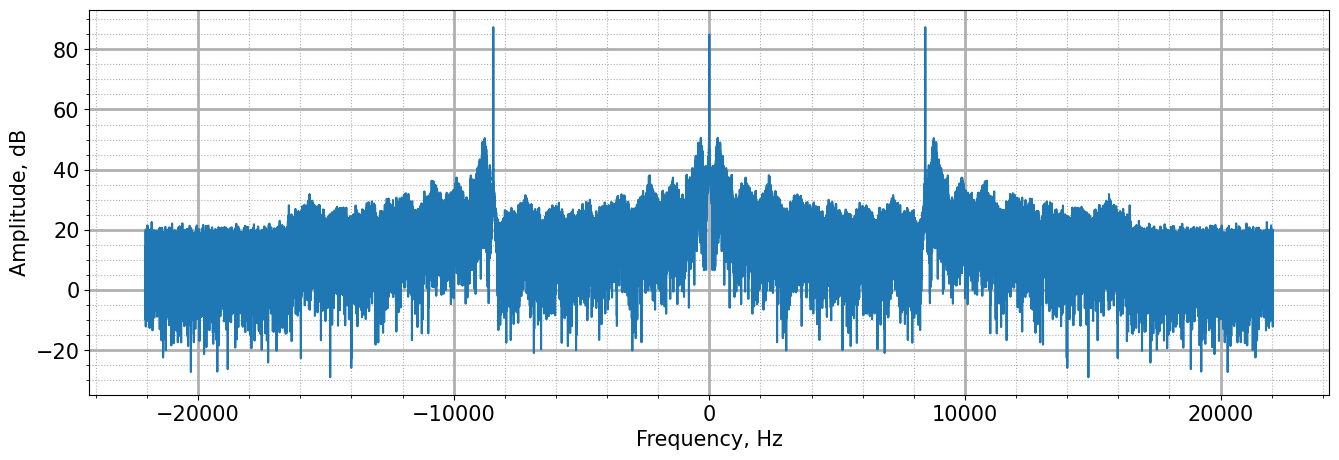

In [63]:
plotAmplFreqResp(restored_signal, Fs, True)

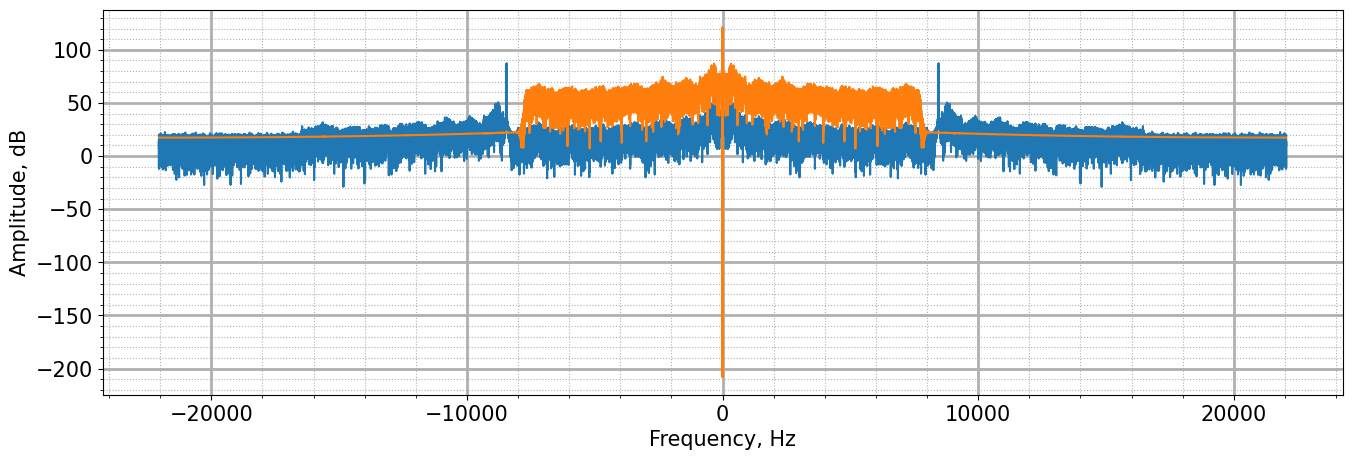

In [64]:
plotAmplFreqResp(restored_signal, Fs, True)
plotAmplFreqResp(filtered_signal, Fs, True)

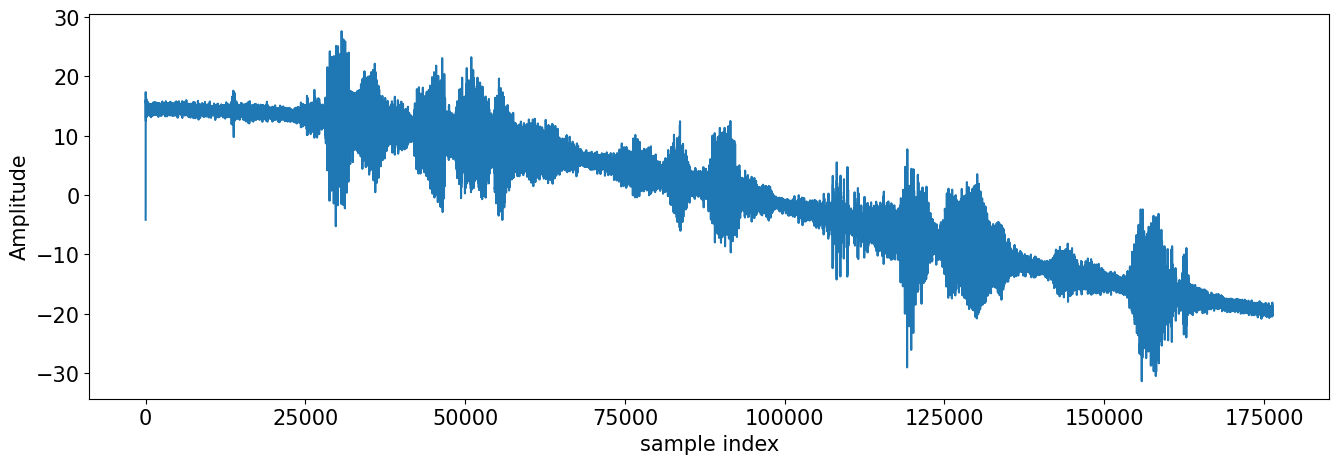

In [65]:

plotSignalTime(filtered_signal)

In [66]:
# Write resulting audio to audio file #

norm_filtered_signal = filtered_signal/max(filtered_signal) #normalize signal, otherwise wavio.write clips it
wavio.write("sounds/result_secret_2.wav", norm_filtered_signal, Fs, sampwidth=2)

Еще Шерлок: "Самый совершенный в мире мозг ржавеет без дела".

У меня так еще дедушка говорил :))

# MAIN HOMEWORK - Frequency/Phase modulation (+6)

Make an separate analogous python notebook  

- HW10*: Make Frequency modulation example (+0.5)

- HW11: Modulate sound using FM

- HW12: Demodulate FM signal

- HW13*: Demodulate secret FM signal (+0.5)
--- Produce your own "secret" FM signal (make signal for future ). Get creative with the audio :)
--- Make comments about how it was created. 
--- Write code to demodulate it.

- HW14*: Make Phase modulatation (+2)
--- Reuse your ready Frequency modulator. (See slides on how to do it) 
--- Do all the same steps (aka HW10-HW13)